In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings

# Ignore unnecessary warnings for a cleaner output
warnings.filterwarnings('ignore')

# Import tools for data splitting, scaling, and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Download dataset path
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# Load data into DataFrame
df = pd.read_csv(f"{path}/creditcard.csv")

# Print number of rows
print("data uploaded successfully. number of rows: ", df.shape[0])

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud
data uploaded successfully. number of rows:  284807


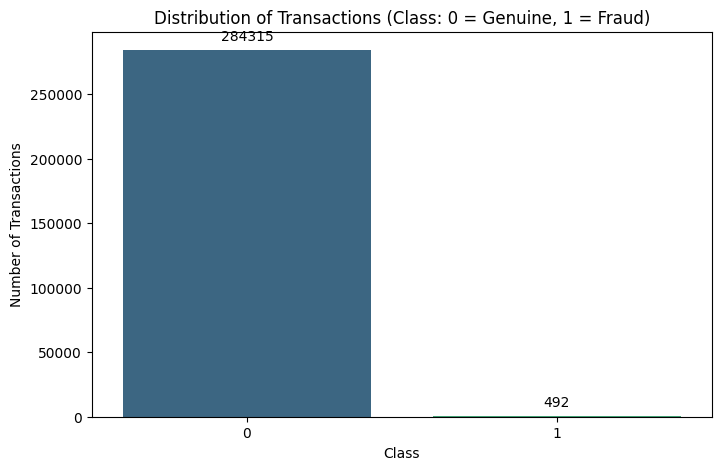

In [2]:
# (Class Distribution) to drawing sample distribtion
plt.figure(figsize=(8, 5))

# Plotting the 'Class' column to see how many transactions are fraud vs. genuine
ax = sns.countplot(x='Class', data=df, palette='viridis')

# Adding the exact count on top of each bar for better clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Distribution of Transactions (Class: 0 = Genuine, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')

# Exporting the plot to use it in our final PDF report
plt.savefig('distribution_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
# 1. Handling Imbalance: Randomly sampling 'Normal' cases to match the number of 'Fraud' cases
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]
normal_sample = normal.sample(n=len(fraud), random_state=42)
balanced_df = pd.concat([fraud, normal_sample], axis=0)

# 2. Shuffling: Mixing the data so the model doesn't learn any specific order
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Preprocessing: Splitting the data and scaling features for better model performance
X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling is crucial, especially for the Neural Network we will use later
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Data is now balanced. Training set shape: {X_train.shape}")

Data is now balanced. Training set shape: (787, 30)


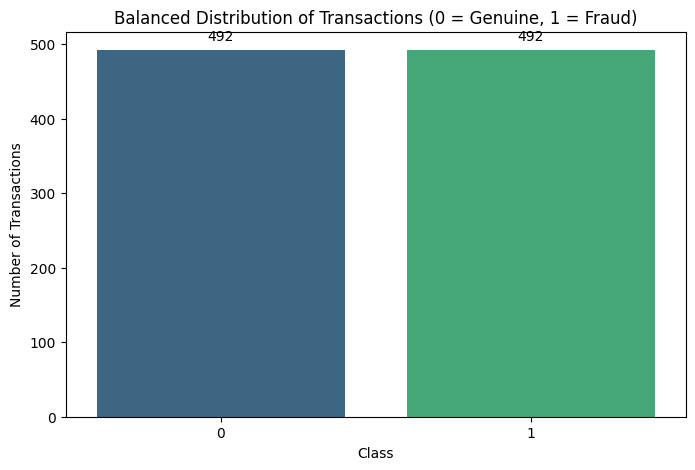

In [4]:
# Plot balanced class distribution
plt.figure(figsize=(8, 5))

# Use 'balanced_df' instead of 'df'
ax = sns.countplot(x='Class', data=balanced_df, palette='viridis')

# Add exact count on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Balanced Distribution of Transactions (0 = Genuine, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')

plt.savefig('balanced_distribution_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Confirming that the data is now perfectly balanced (50/50)
print("Class Distribution in Balanced Data:")
print(balanced_df['Class'].value_counts())

# A quick look at the first 10 rows to ensure the data is well-shuffled
print("\nFirst 10 rows of data (to check shuffling results):")
print(balanced_df.head(10))

Class Distribution in Balanced Data:
Class
0    492
1    492
Name: count, dtype: int64

First 10 rows of data (to check shuffling results):
       Time        V1        V2         V3        V4        V5        V6  \
0  157278.0  1.984787 -1.937036   0.486613 -1.245536 -2.518536 -0.544524   
1  153875.0 -0.613696  3.698772  -5.534941  5.620486  1.649263 -2.335145   
2   56424.0  0.319007 -1.072867  -0.216146  1.494709 -0.627063 -0.761867   
3  150139.0 -6.682832 -2.714268  -5.774530  1.449792 -0.661836 -1.148650   
4   85285.0 -6.713407  3.921104  -9.746678  5.148263 -5.151563 -2.099389   
5  107492.0  1.752037 -0.254467  -1.490596  0.671397  0.128310 -0.738187   
6   84738.0 -2.501943  1.580387   1.506315  0.959038 -1.862246  0.051051   
7   93853.0 -5.839192  7.151532 -12.816760  7.031115 -9.651272 -2.938427   
8   64222.0 -0.621770  1.037445   0.367377  0.582815  0.196312  0.289307   
9   55125.0 -0.391128 -0.245540   1.122074 -1.308725 -0.639891  0.008678   

          V7        V8 

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 1. Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# 2. Train K-Nearest Neighbors (KNN) model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("Both models have been trained successfully.")

Both models have been trained successfully.


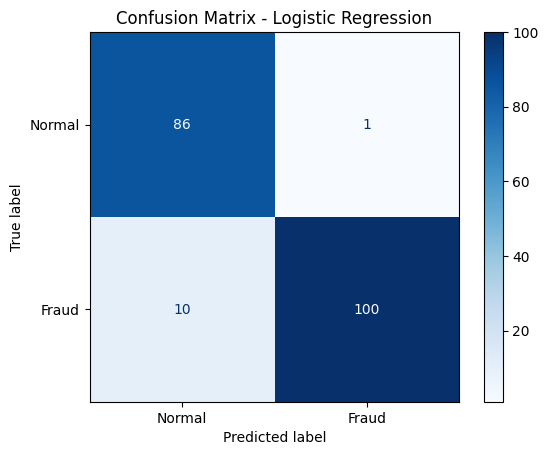

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict using Logistic Regression
y_pred_lr = lr_model.predict(X_test)

# Create and plot confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Normal', 'Fraud'])

disp_lr.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')

# Save and show plot
plt.savefig('confusion_matrix_LR.png', dpi=300, bbox_inches='tight')
plt.show()

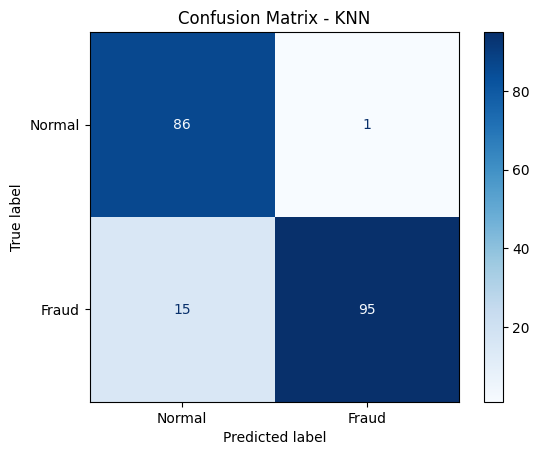

In [8]:
# Predict using KNN
y_pred_knn = knn_model.predict(X_test)

# Create and plot confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Normal', 'Fraud'])

disp_knn.plot(cmap='Blues')
plt.title('Confusion Matrix - KNN')

# Save and show plot
plt.savefig('confusion_matrix_KNN.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Print the classification report for the Logistic Regression model
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))

# Print a separator line for better readability
print("\n" + "="*50 + "\n")

# Print the classification report for the K-Nearest Neighbors (KNN) model
print("--- KNN Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=['Normal', 'Fraud']))

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Normal       0.90      0.99      0.94        87
       Fraud       0.99      0.91      0.95       110

    accuracy                           0.94       197
   macro avg       0.94      0.95      0.94       197
weighted avg       0.95      0.94      0.94       197



--- KNN Classification Report ---
              precision    recall  f1-score   support

      Normal       0.85      0.99      0.91        87
       Fraud       0.99      0.86      0.92       110

    accuracy                           0.92       197
   macro avg       0.92      0.93      0.92       197
weighted avg       0.93      0.92      0.92       197

